# Proyek Analisis Data: E-Commerce Public Dataset (Olist)

- **Nama:** Salzabila Triana Said
- **Dataset:** E-Commerce Public Dataset (Olist Brazilian E-Commerce)

## Menentukan Pertanyaan Bisnis

1. **Bagaimana tren jumlah pesanan (order) secara bulanan (Month-over-Month) sepanjang Januari 2017 - Agustus 2018, dan 5 kategori produk apa yang menyumbang revenue tertinggi selama periode tersebut?**
   - *Specific*: fokus pada tren jumlah order bulanan dan kategori produk dengan revenue tertinggi.
   - *Measurable*: dihitung dari jumlah order unik per bulan dan total revenue (price + freight) per kategori.
   - *Action-Oriented*: hasil dipakai untuk menentukan kategori mana yang perlu diprioritaskan dalam stok & promosi, serta mengantisipasi bulan-bulan puncak permintaan.
   - *Relevant*: langsung berkaitan dengan strategi penjualan dan perencanaan inventori.
   - *Time-bound*: dibatasi periode Januari 2017 - Agustus 2018 (rentang data yang representatif, di luar bulan-bulan dengan data sangat minim di ujung dataset).

2. **Berapa perbedaan rata-rata skor ulasan (review score) antara pesanan yang terlambat dikirim (delivered date > estimated date) dengan pesanan yang tepat waktu, pada seluruh pesanan berstatus *delivered*?**
   - *Specific*: fokus pada perbandingan review score berdasarkan status keterlambatan pengiriman.
   - *Measurable*: dihitung dari rata-rata `review_score` untuk grup terlambat vs tepat waktu.
   - *Action-Oriented*: jika keterlambatan terbukti menurunkan kepuasan pelanggan secara signifikan, tim logistik dapat memprioritaskan perbaikan SLA pengiriman.
   - *Relevant*: kepuasan pelanggan dan retensi sangat dipengaruhi oleh pengalaman pengiriman.
   - *Time-bound*: mencakup seluruh pesanan *delivered* dalam dataset (2016-2018).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## Data Wrangling

### Gathering Data

Dataset terdiri dari beberapa berkas CSV yang saling berelasi (customers, orders, order_items, order_payments, order_reviews, products, dan product_category_name_translation). Semua berkas dimuat ke dalam DataFrame terpisah terlebih dahulu.

In [2]:
base_path = "data/"

customers = pd.read_csv(base_path + "customers_dataset.csv")
orders = pd.read_csv(base_path + "orders_dataset.csv")
order_items = pd.read_csv(base_path + "order_items_dataset.csv")
payments = pd.read_csv(base_path + "order_payments_dataset.csv")
reviews = pd.read_csv(base_path + "order_reviews_dataset.csv")
products = pd.read_csv(base_path + "products_dataset.csv")
category_translation = pd.read_csv(base_path + "product_category_name_translation.csv")

print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("payments:", payments.shape)
print("reviews:", reviews.shape)
print("products:", products.shape)
print("category_translation:", category_translation.shape)


customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
category_translation: (71, 2)


In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


### Assessing Data

Pada tahap ini dilakukan pengecekan terhadap beberapa potensi masalah kualitas data: **missing value**, **duplicate data**, **tipe data yang tidak sesuai**, dan **nilai kategori yang belum diterjemahkan**.

In [5]:
# 1. Cek missing value pada tabel orders
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

**Temuan:** Terdapat missing value pada `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`. Setelah ditelusuri, nilai kosong ini terjadi pada order yang belum sampai ke tahap tersebut (misalnya berstatus *canceled* atau *unavailable*), sehingga bukan merupakan error, namun tetap perlu ditangani sebagai representasi "belum terjadi" (tidak dihapus, dibiarkan sebagai NaT lalu difilter sesuai konteks analisis).

In [6]:
# 2. Cek tipe data kolom tanggal (masih berupa object/string, seharusnya datetime)
orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

In [7]:
# 3. Cek duplicate data
print("Duplikat orders:", orders.duplicated().sum())
print("Duplikat order_items:", order_items.duplicated().sum())
print("Duplikat customers:", customers.duplicated().sum())
print("Duplikat products:", products.duplicated().sum())

Duplikat orders: 0
Duplikat order_items: 0
Duplikat customers: 0
Duplikat products: 0


In [8]:
# 4. Cek missing value pada products, khususnya kategori produk
products.isna().sum().sort_values(ascending=False).head()

product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
dtype: int64

**Temuan:** Terdapat produk dengan `product_category_name` kosong. Selain itu, nama kategori masih berbahasa Portugis sehingga perlu diterjemahkan menggunakan tabel `category_translation` agar mudah dipahami.

In [9]:
# 5. Cek order_status yang tidak relevan untuk analisis delay (order yang belum delivered)
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### Cleaning Data

Berdasarkan temuan di tahap Assessing Data, dilakukan langkah-langkah berikut:

1. Mengonversi seluruh kolom tanggal pada tabel `orders` menjadi tipe `datetime`.
2. Menerjemahkan `product_category_name` ke bahasa Inggris melalui `category_translation`, dan mengisi kategori yang hilang dengan label `"unknown"`.
3. Mengagregasi `order_payments` (yang bisa memiliki beberapa baris per order karena multi-payment) menjadi total pembayaran per order.
4. Mengagregasi `order_reviews` menjadi satu skor rata-rata per order.
5. Menggabungkan seluruh tabel menjadi satu DataFrame analisis (`main_df`) pada level order-item.

In [10]:
date_cols = ["order_purchase_timestamp", "order_approved_at",
             "order_delivered_carrier_date", "order_delivered_customer_date",
             "order_estimated_delivery_date"]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

orders.dtypes[date_cols]

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [11]:
products = products.merge(category_translation, on="product_category_name", how="left")
products["product_category_name_english"] = products["product_category_name_english"].fillna("unknown")

payment_agg = payments.groupby("order_id", as_index=False)["payment_value"].sum()
review_agg = reviews.groupby("order_id", as_index=False)["review_score"].mean()

print("Kategori unik setelah cleaning:", products["product_category_name_english"].nunique())

Kategori unik setelah cleaning: 72


In [12]:
main_df = order_items.merge(orders, on="order_id", how="left")
main_df = main_df.merge(customers, on="customer_id", how="left")
main_df = main_df.merge(products[["product_id", "product_category_name_english"]], on="product_id", how="left")
main_df = main_df.merge(payment_agg, on="order_id", how="left")
main_df = main_df.merge(review_agg, on="order_id", how="left")

main_df.rename(columns={"product_category_name_english": "product_category"}, inplace=True)
main_df["product_category"] = main_df["product_category"].fillna("unknown")

# Kolom turunan untuk analisis
main_df["revenue"] = main_df["price"] + main_df["freight_value"]
main_df["delivery_delay_days"] = (main_df["order_delivered_customer_date"] - main_df["order_estimated_delivery_date"]).dt.days
main_df["is_late"] = main_df["delivery_delay_days"] > 0
main_df["order_purchase_month"] = main_df["order_purchase_timestamp"].dt.to_period("M").astype(str)

print(main_df.shape)
main_df.head()

(112650, 25)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category,payment_value,review_score,revenue,delivery_delay_days,is_late,order_purchase_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,cool_stuff,72.19,5.0,72.19,-9.0,False,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,pet_shop,259.83,4.0,259.83,-3.0,False,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,furniture_decor,216.87,5.0,216.87,-14.0,False,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,perfumery,25.78,4.0,25.78,-6.0,False,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,garden_tools,218.04,5.0,218.04,-16.0,False,2017-02


In [13]:
# Cek akhir: pastikan tidak ada duplikat baris penuh, dan lihat ringkasan missing value akhir
print("Duplikat main_df:", main_df.duplicated().sum())
main_df.isna().sum().sort_values(ascending=False).head(8)

Duplikat main_df: 0


order_delivered_customer_date    2454
delivery_delay_days              2454
order_delivered_carrier_date     1194
review_score                      942
order_approved_at                  15
payment_value                       3
product_id                          0
order_item_id                       0
dtype: int64

Missing value yang tersisa (`order_delivered_customer_date`, `delivery_delay_days`, `review_score`, dst.) berasal dari order yang memang belum terkirim atau belum memiliki ulasan — ini adalah kondisi valid dalam bisnis, bukan error, sehingga baris-baris ini **tidak dihapus** dari dataset utama, namun akan difilter sesuai kebutuhan tiap analisis.

Dataset bersih `main_df` disimpan sebagai `main_data.csv` untuk digunakan pada dashboard Streamlit.

In [14]:
main_df.to_csv("main_data.csv", index=False)

## Exploratory Data Analysis (EDA)

### Pertanyaan 1: Tren order bulanan & kategori dengan revenue tertinggi

In [15]:
# Filter periode yang representatif (Jan 2017 - Aug 2018), buang bulan dengan data sangat minim di ujung dataset
valid_months = [m for m in main_df["order_purchase_month"].unique() if "2016" not in m and m != "2018-09"]
df_period = main_df[main_df["order_purchase_month"].isin(valid_months)]

monthly_orders = df_period.drop_duplicates("order_id").groupby("order_purchase_month")["order_id"].nunique().sort_index()
monthly_orders

order_purchase_month
2017-01     789
2017-02    1733
2017-03    2641
2017-04    2391
2017-05    3660
2017-06    3217
2017-07    3969
2017-08    4293
2017-09    4243
2017-10    4568
2017-11    7451
2017-12    5624
2018-01    7220
2018-02    6694
2018-03    7188
2018-04    6934
2018-05    6853
2018-06    6160
2018-07    6273
2018-08    6452
Name: order_id, dtype: int64

In [16]:
top_categories = main_df.groupby("product_category")["revenue"].sum().sort_values(ascending=False).head(5)
top_categories

product_category
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
Name: revenue, dtype: float64

### Pertanyaan 2: Review score untuk pesanan terlambat vs tepat waktu

In [17]:
delivered = main_df[main_df["order_status"] == "delivered"].drop_duplicates("order_id")
delay_summary = delivered.groupby("is_late").agg(
    avg_review_score=("review_score", "mean"),
    jumlah_order=("order_id", "count")
)
delay_summary

,avg_review_score,jumlah_order
is_late,,
False,4.290608,89944
True,2.271823,6534


In [18]:
# Rata-rata & median keterlambatan pada order yang terlambat
late_orders = delivered[delivered["is_late"]]
print("Rata-rata keterlambatan (hari):", round(late_orders["delivery_delay_days"].mean(), 1))
print("Median keterlambatan (hari):", late_orders["delivery_delay_days"].median())
print("Persentase order terlambat: {:.2f}%".format(100 * delivered["is_late"].mean()))

Rata-rata keterlambatan (hari): 10.6
Median keterlambatan (hari): 7.0
Persentase order terlambat: 6.77%


## Visualization & Explanatory Analysis

### Visualisasi 1 — Tren Jumlah Order Bulanan (Jan 2017 - Agu 2018)

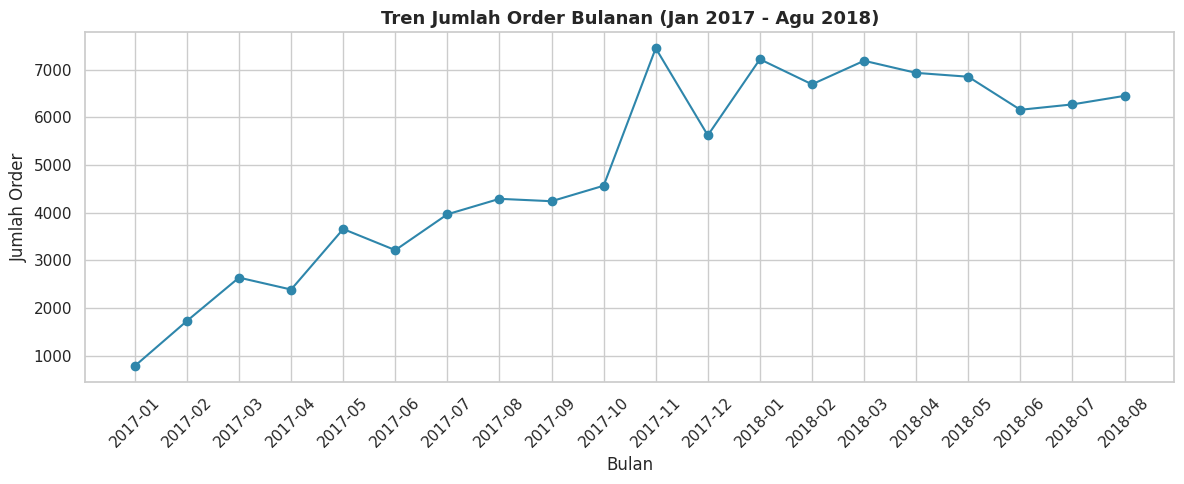

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_orders.index, monthly_orders.values, marker="o", color="#2E86AB")
ax.set_title("Tren Jumlah Order Bulanan (Jan 2017 - Agu 2018)", fontsize=13, fontweight="bold")
ax.set_xlabel("Bulan")
ax.set_ylabel("Jumlah Order")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_orders_trend.png", dpi=150)
plt.show()

**Insight:** Jumlah order menunjukkan tren pertumbuhan yang konsisten dari awal 2017 hingga November 2017 (puncak musiman, kemungkinan terkait Black Friday), kemudian relatif stabil tinggi di level 6.000-7.000 order/bulan sepanjang 2018.

### Visualisasi 2 — Top 5 Kategori Produk Berdasarkan Revenue

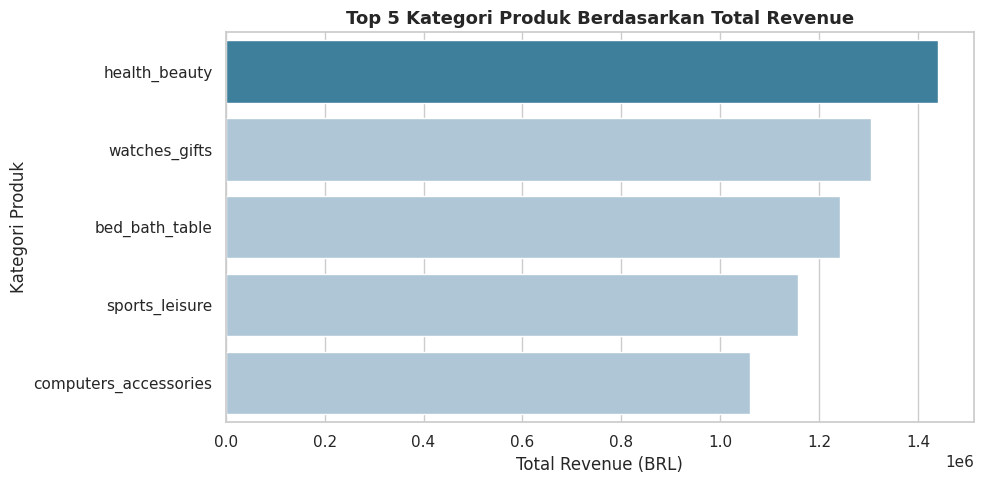

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2E86AB" if i == 0 else "#A9C7DD" for i in range(len(top_categories))]
sns.barplot(x=top_categories.values, y=top_categories.index, hue=top_categories.index, palette=colors, legend=False, ax=ax)
ax.set_title("Top 5 Kategori Produk Berdasarkan Total Revenue", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Revenue (BRL)")
ax.set_ylabel("Kategori Produk")
plt.tight_layout()
plt.savefig("top5_categories_revenue.png", dpi=150)
plt.show()

**Insight:** Kategori `health_beauty` menyumbang revenue tertinggi, diikuti oleh `watches_gifts`, `bed_bath_table`, `sports_leisure`, dan `computers_accessories`. Kelima kategori ini layak menjadi prioritas dalam alokasi stok dan kampanye promosi.

### Visualisasi 3 — Review Score: Pesanan Terlambat vs Tepat Waktu

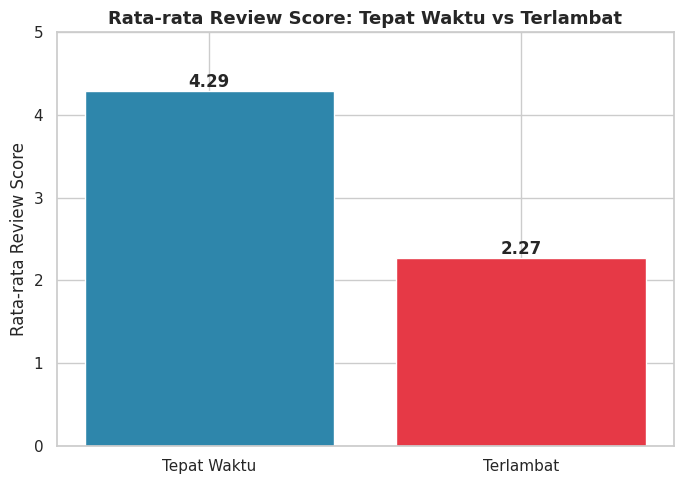

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["Tepat Waktu", "Terlambat"]
values = [delay_summary.loc[False, "avg_review_score"], delay_summary.loc[True, "avg_review_score"]]
bars = ax.bar(labels, values, color=["#2E86AB", "#E63946"])
ax.set_title("Rata-rata Review Score: Tepat Waktu vs Terlambat", fontsize=13, fontweight="bold")
ax.set_ylabel("Rata-rata Review Score")
ax.set_ylim(0, 5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("review_score_by_delay.png", dpi=150)
plt.show()

**Insight:** Pesanan yang terlambat memiliki rata-rata review score jauh lebih rendah (±2.27) dibandingkan pesanan yang tepat waktu (±4.29). Ini menunjukkan keterlambatan pengiriman berdampak besar terhadap kepuasan pelanggan.

## Conclusion & Recommendation

### Kesimpulan

1. **Pertanyaan 1 (Tren order & kategori teratas):** Jumlah order tumbuh signifikan sepanjang 2017 dan stabil di level tinggi (6.000-7.000 order/bulan) sepanjang 2018, dengan lonjakan musiman di November 2017. Lima kategori dengan revenue tertinggi adalah `health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, dan `computers_accessories`.
2. **Pertanyaan 2 (Keterlambatan vs review score):** Sekitar 6-7% pesanan mengalami keterlambatan pengiriman, dan pesanan yang terlambat memiliki rata-rata review score jauh lebih rendah (2.27) dibandingkan pesanan tepat waktu (4.29) — selisih hampir 2 poin dari skala 5.

### Rekomendasi (Action Items)

1. **Prioritaskan perbaikan SLA logistik**, terutama untuk rute/kurir dengan tingkat keterlambatan tinggi, karena keterlambatan terbukti secara signifikan menurunkan kepuasan pelanggan (review score).
2. Alokasikan stok dan anggaran promosi lebih besar untuk 5 kategori produk dengan revenue tertinggi (`health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, `computers_accessories`), terutama menjelang periode puncak seperti November.
3. Bangun dashboard monitoring (lihat `dashboard.py`) agar tim operasional dapat memantau tren order dan tingkat keterlambatan secara berkala, bukan hanya sebagai analisis satu kali.
